# Cannon dynamics

In [7]:
# state: x, y, vx, vy
# control: init vx, vy
import numpy as np
from scipy.integrate import solve_ivp

class CannonSimulator:
    c:float
    g:float = 9.8
    def __init__(self, c):
        self.c = c
    
    def dynamics(self, state, control, dt):
        x, y, vx, vy = state
        
        dx = vx
        dy = vy
        v = np.sqrt(vx**2 + vy**2)
        dvx = -self.c * v * vx
        dvy = -self.c * v * vy - self.g
        return [dx, dy, dvx, dvy]

    def step(self, state, control, dt):
        x, y, vx, vy = state
        return solve_ivp(lambda t, s: self.dynamics(s, control, dt), [0, dt], state).y[:, -1]


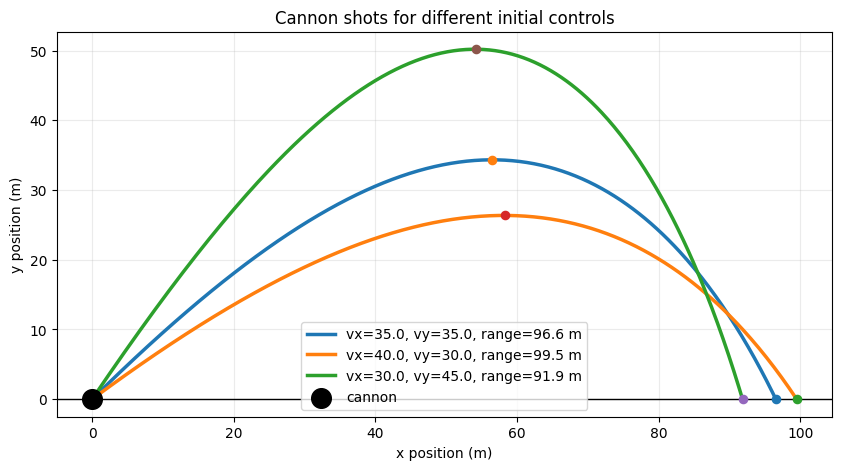

In [8]:
import matplotlib.pyplot as plt

def simulate_shot(control, c=0.01, dt=0.02, max_time=20.0):
    sim = CannonSimulator(c=c)
    control = np.asarray(control, dtype=float)
    state = np.array([0.0, 0.0, control[0], control[1]])
    trajectory = [state.copy()]

    for _ in range(int(max_time / dt)):
        prev_state = state.copy()
        state = sim.step(state, control, dt)

        if state[1] < 0:
            # The last integration step crossed the ground, so interpolate between
            # the previous positive-y state and the current negative-y state.
            alpha = prev_state[1] / (prev_state[1] - state[1])
            landing_state = prev_state + alpha * (state - prev_state)
            trajectory.append(landing_state)
            break

        trajectory.append(state.copy())

    return np.array(trajectory)


def plot_shot(control, c=0.01, dt=0.02, max_time=20.0, ax=None, label=None):
    trajectory = simulate_shot(control, c=c, dt=dt, max_time=max_time)
    x = trajectory[:, 0]
    y = trajectory[:, 1]
    apex_index = np.argmax(y)
    range_x = x[-1]
    max_height = y[apex_index]

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))

    if label is None:
        label = f"vx={control[0]:.1f}, vy={control[1]:.1f}, range={range_x:.1f} m"

    ax.plot(x, y, linewidth=2.5, label=label)
    ax.scatter([range_x], [0], s=35, zorder=5)
    ax.scatter([x[apex_index]], [max_height], s=35, zorder=5)
    return trajectory


controls = [
    np.array([35.0, 35.0]),
    np.array([40.0, 30.0]),
    np.array([30.0, 45.0]),
]

fig, ax = plt.subplots(figsize=(10, 5))
trajectories = [plot_shot(control, ax=ax) for control in controls]

ax.axhline(0, color="black", linewidth=1)
ax.scatter([0], [0], s=200, color="black", zorder=5, label="cannon")
ax.set_title("Cannon shots for different initial controls")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


# Single shooting
Only change init state, use simulation to optimize.

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 1261.8033635356517
           x: [ 3.964e+01  3.086e+01]
         nit: 8
         jac: [ 3.964e+01  3.086e+01]
        nfev: 24
        njev: 8
 multipliers: [ 2.662e+01]
best control: [39.64044814 30.85841211]
initial energy: 1261.8033635356517
range error: -1.9297061726319953e-09


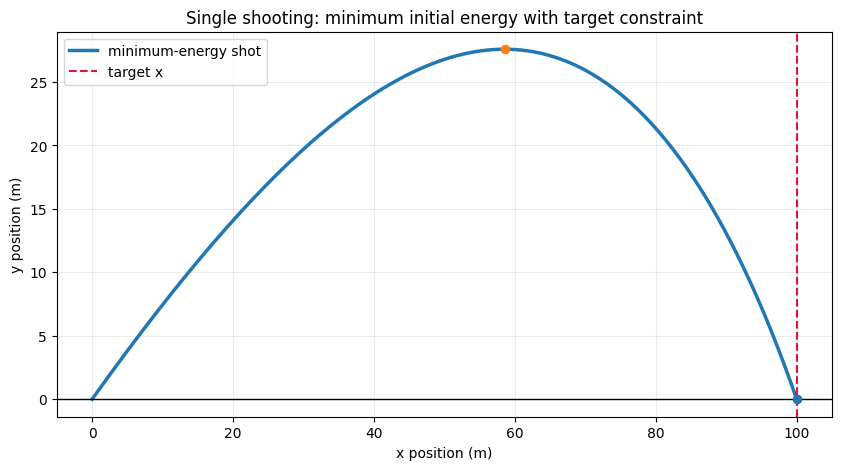

In [15]:
from scipy.optimize import minimize

# Single shooting with minimum initial energy:
# 1. Decision variable z = [vx0, vy0].
# 2. Objective: minimize initial kinetic energy.
# 3. Constraint: after one simulated shot, the landing x should match target_x.
#
# Why not just use target error + energy in one loss?
# That is a penalty method. It is useful, but the weight decides the trade-off.
# Here, SLSQP lets us say the real goal more directly:
# "hit the target, and among those shots, use the least initial energy."

target_x = 100.0

target_y = 0.0  # landing interpolation already makes final y close to 0
mass = 1.0      # use 1 kg for now, so energy mainly compares control size

initial_guess = np.array([45.0, 40.0])
bounds = [
    (0.0, 100.0),  # vx0 lower/upper bound
    (0.0, 100.0),  # vy0 lower/upper bound
]


def initial_energy_objective(z):
    """Objective function: minimize initial kinetic energy.

    Your task:
    - Read z as [vx0, vy0].
    - Use E = 1/2 * m * (vx0^2 + vy0^2).
    - Return one scalar energy value.
    """
    control = np.asarray(z, dtype=float)

    # TODO: unpack vx0 and vy0 from control.
    # TODO: compute and return initial kinetic energy.
    vx0, vy0 = control
    energy = 0.5 * mass * (vx0**2 + vy0**2)
    return energy


def target_range_constraint(z):
    """Equality constraint for SLSQP.

    SLSQP treats this as satisfied when the returned value is close to 0.
    For this problem, return: landing_x - target_x.
    """
    control = np.asarray(z, dtype=float)
    trajectory = simulate_shot(control, c=0.01, dt=0.02, max_time=20.0)
    final_state = trajectory[-1]

    # TODO: extract landing_x from final_state.
    # Hint: state format is [x, y, vx, vy].
    landing_x = final_state[0]

    # TODO: return landing_x - target_x.
    return landing_x - target_x


constraints = [
    {"type": "eq", "fun": target_range_constraint},
]


# After you finish the two TODO functions, uncomment this block:
result = minimize(
    initial_energy_objective,
    initial_guess,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
)

best_control = result.x
print(result)
print("best control:", best_control)
print("initial energy:", initial_energy_objective(best_control))
print("range error:", target_range_constraint(best_control))

fig, ax = plt.subplots(figsize=(10, 5))
best_trajectory = plot_shot(best_control, ax=ax, label="minimum-energy shot")
ax.axvline(target_x, color="crimson", linestyle="--", label="target x")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Single shooting: minimum initial energy with target constraint")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


# Multiple Shooting
Split to multple segments, and use defects to constrain the path